In [2]:
#Importamos librerias a utilizar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Leer Dataset 
df = pd.read_csv('data/superstore.csv', encoding='latin1')

In [3]:
# 2. Mostrar primeras filas
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [4]:
# 3. Agregar 4 columnas nuevas
df["Nombre Producto"]= df["Product Name"]
df["Total"] = df["Sales"] * df["Quantity"]                    # Valor total de la venta
df["Año"] = pd.to_datetime(df["Order Date"]).dt.year          # Extraer año
df["Mes"] = pd.to_datetime(df["Order Date"]).dt.month         # Extraer mes
df["Precio_con_Descuento"] = df["Sales"] - df["Discount"]     # Precio con Descuento

print(df[["Nombre Producto", "Año", "Mes", "Precio_con_Descuento", "Total"]].head())

                                     Nombre Producto   Año  Mes  \
0                  Bush Somerset Collection Bookcase  2016   11   
1  Hon Deluxe Fabric Upholstered Stacking Chairs,...  2016   11   
2  Self-Adhesive Address Labels for Typewriters b...  2016    6   
3      Bretford CR4500 Series Slim Rectangular Table  2015   10   
4                     Eldon Fold 'N Roll Cart System  2015   10   

   Precio_con_Descuento      Total  
0              261.9600   523.9200  
1              731.9400  2195.8200  
2               14.6200    29.2400  
3              957.1275  4787.8875  
4               22.1680    44.7360  


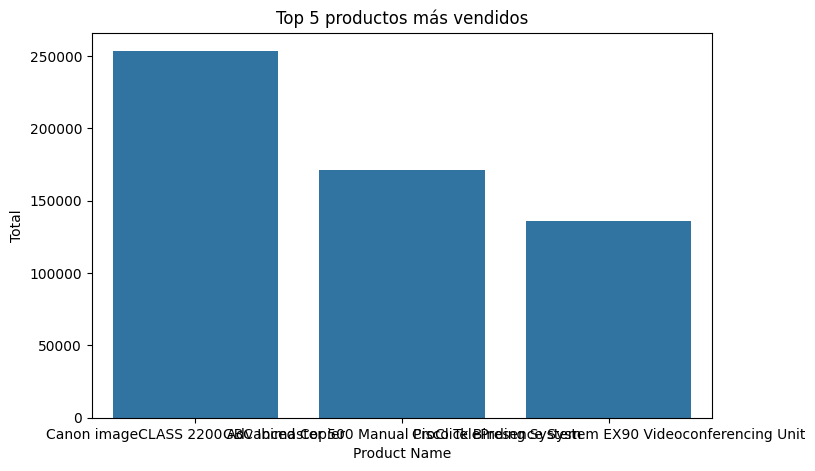

In [5]:
# 4. Visualización 1: Ventas por producto
# Calcular ventas totales por producto
ventas_por_producto = df.groupby("Product Name")["Total"].sum().reset_index()

# Ordenar de mayor a menor y seleccionar los 5 primeros
top5 = ventas_por_producto.sort_values(by="Total", ascending=False).head(3)

# Gráfico: Top 5 productos más vendidos
plt.figure(figsize=(8,5))
sns.barplot(x="Product Name", y="Total", data=top5)
plt.title("Top 5 productos más vendidos")
plt.show()

C:\Users\edyba\AppData\Local\Temp\ipykernel_18540\2205274387.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x="Mes", y="Total", data=df, estimator=sum, ci=None)


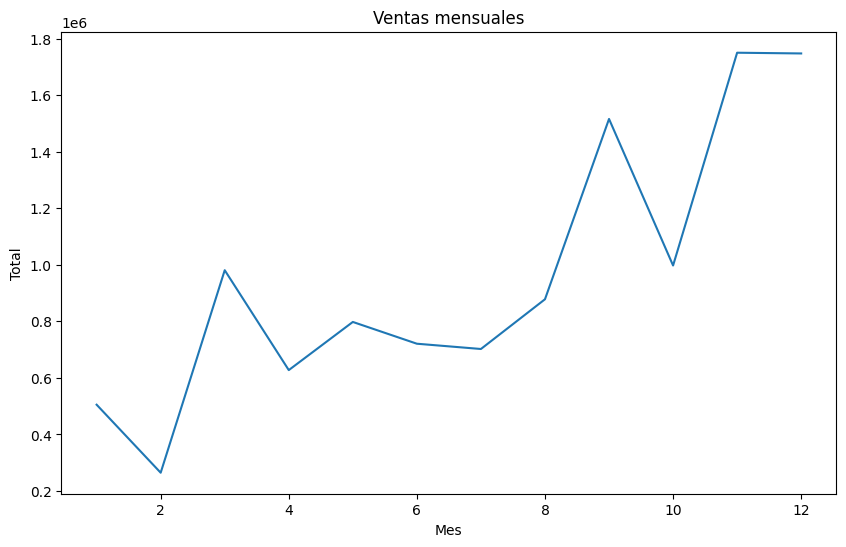

In [6]:
#5. Visualización 2: Evolución mensual de ventas
plt.figure(figsize=(10,6))
sns.lineplot(x="Mes", y="Total", data=df, estimator=sum, ci=None)
plt.title("Ventas mensuales")
plt.show()